# d51: Catalyst Screens And TS Guess Construction

This notebook is a code-level walkthrough of the new `ft.screen` and
`frust.tsguess` workflow. It is meant to be read and executed cell by cell.

The goal is to make the construction visible:

```text
substrate/catalyst SMILES
    -> component table
    -> expanded substrate-catalyst systems
    -> dynamic atom roles
    -> template-anchored TS1-TS4 geometries
    -> row-level constrained Stepper calculations
```

The important conceptual shift from the old transformer workflow is this:

```text
old workflow:
    load a specific XYZ template -> graft substrate atoms into that template

new screen workflow:
    parse catalyst/substrate SMILES -> find chemical roles dynamically
    -> place those roles on built-in TS template coordinates
```

So this is still template chemistry. The difference is that the template is now
role-based instead of fixed-index based. Once FRUST finds a valid B-aryl-N
catalyst scaffold and a substrate `rpos`, it can assemble the same TS motif for
different related catalysts and substrates.


## Interaction Notes

The 3D viewers in this notebook use `ft.MolTo3DGrid` and `ft.plot_row` from
FRUST's visualization module.

In the 3D viewers:

- click an atom to toggle its atom index label;
- Ctrl-click two atoms to measure a distance;
- Shift-click three atoms to measure an angle.

Most role atoms are pre-labeled and highlighted. Use the constraint tables next
to each structure to decide exactly which atoms to measure.


In [30]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from rdkit import Chem

import frust as ft
from frust.constraints import render_orca_constraints, render_xtb_constraints
from frust.tsguess.matching import match_catalyst_roles, mol_from_smiles, parse_rpos_value
from frust.tsguess.specs import BUILTIN_TS_SPECS
from frust.vis.molecules import _row_to_mol

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)

ROOT = Path.cwd()
if ROOT.name == "dev":
    ROOT = ROOT.parent

print(f"Working from: {ROOT}")


Working from: /Users/jacobmolinnielsen/Developer/FrustActivationProject/FRUST


In [31]:
def role_indices(row):
    # Return role atom indices in a stable display order.
    return [int(idx) for _, idx in sorted(row["constraint_roles"].items())]


def row_to_role_mol(row, coord_col="coords_embedded"):
    # Create an RDKit molecule from one FRUST row and label role atoms.
    mol = Chem.Mol(_row_to_mol(row, row["atoms"], row[coord_col]))
    role_by_idx = {
        int(idx): role
        for role, idx in row["constraint_roles"].items()
    }
    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        if idx in role_by_idx:
            atom.SetProp("atomNote", f"{role_by_idx[idx]}:{idx}")
    return mol


def show_role_rows(rows, legends=None, coord_col="coords_embedded", columns=2, linked=False):
    # Show TS rows as labeled and highlighted 3D structures.
    rows = list(rows)
    mols = [row_to_role_mol(row, coord_col=coord_col) for row in rows]
    highlights = [role_indices(row) for row in rows]
    if legends is None:
        legends = [row["custom_name"] for row in rows]
    ft.MolTo3DGrid(
        mols,
        legends=legends,
        highlightAtoms=highlights,
        show_labels=False,
        show_confs=False,
        columns=columns,
        linked=linked,
        cell_size=(520, 460),
        kekulize=True,
        show_charges=True,
    )


def distance(coords, atom_i, atom_j):
    return float(np.linalg.norm(coords[int(atom_i)] - coords[int(atom_j)]))


def angle(coords, atom_i, atom_j, atom_k):
    a = coords[int(atom_i)] - coords[int(atom_j)]
    b = coords[int(atom_k)] - coords[int(atom_j)]
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    cosine = float(np.dot(a, b) / denom)
    cosine = max(-1.0, min(1.0, cosine))
    return float(np.degrees(np.arccos(cosine)))


def constraint_table(row, coord_col="coords_embedded"):
    # Return measured distances/angles for a row's role constraints.
    roles = row["constraint_roles"]
    coords = np.asarray(row[coord_col], dtype=float)
    records = []
    for item in row["constraint_spec"]:
        role_names = list(item["roles"])
        atoms = [int(roles[role]) for role in role_names]
        if item["kind"] == "distance":
            measured = distance(coords, atoms[0], atoms[1])
        elif item["kind"] == "angle":
            measured = angle(coords, atoms[0], atoms[1], atoms[2])
        else:
            measured = np.nan
        records.append(
            {
                "kind": item["kind"],
                "roles": "-".join(role_names),
                "atoms": "-".join(str(atom) for atom in atoms),
                "target": round(float(item["value"]), 3),
                "measured": round(float(measured), 3),
                "delta": round(float(measured - float(item["value"])), 3),
            }
        )
    return pd.DataFrame(records)


def roles_table(row):
    # Return one row per chemical role in a TS guess row.
    return pd.DataFrame(
        [
            {
                "role": role,
                "atom_index": int(atom_idx),
                "element": row["atoms"][int(atom_idx)],
            }
            for role, atom_idx in sorted(row["constraint_roles"].items())
        ]
    )


def has_stored_bond(row, role_a, role_b):
    roles = row["constraint_roles"]
    pair = tuple(sorted((int(roles[role_a]), int(roles[role_b]))))
    stored = {tuple(sorted((int(a), int(b)))) for a, b in row["connectivity_bonds"]}
    return pair in stored


def has_distance_constraint(row, role_a, role_b):
    target = {role_a, role_b}
    return any(
        item["kind"] == "distance" and set(item["roles"]) == target
        for item in row["constraint_spec"]
    )


## 1. The Screen Definition

The input file is intentionally boring: it is just a component library. The
important column is `role`, because that tells FRUST whether a row should be
expanded as a substrate or as a catalyst.

Here we use three substrates and two catalysts. The second catalyst is much
smaller than the TMP catalyst, but it still contains one B-aryl-N scaffold, so
it fits the current screen model.


In [32]:
raw_screen = pd.DataFrame(
    {
        "role": ["substrate", "substrate", "substrate", "catalyst", "catalyst"],
        "smiles": [
            "CN1C=CC=C1",
            "C1=CC=CO1",
            "COC1=CC=CO1",
            "CC1(C)CCCC(C)(C)N1C2=CC=CC=C2B",
            "CN(C)c1ccccc1B",
        ],
        "compound_name": [
            "n_methyl_pyrrole",
            "furan",
            "methoxyfuran",
            "tmp_bcat",
            "dimethyl_anilino_bcat",
        ],
        "rpos": ["", "", "3,5", "", ""],
        "series": ["pyrrole", "furan", "furan", "baseline", "small_cat"],
    }
)

raw_screen


,role,smiles,compound_name,rpos,series
0,substrate,CN1C=CC=C1,n_methyl_pyrrole,,pyrrole
1,substrate,C1=CC=CO1,furan,,furan
2,substrate,COC1=CC=CO1,methoxyfuran,"3,5",furan
3,catalyst,CC1(C)CCCC(C)(C)N1C2=CC=CC=C2B,tmp_bcat,,baseline
4,catalyst,CN(C)c1ccccc1B,dimethyl_anilino_bcat,,small_cat


`rpos` is the atom index of the substrate aromatic C-H position. A blank `rpos`
means: use the symmetry-unique aromatic C-H positions FRUST can find.

Before hand-picking `rpos`, inspect the exact SMILES. The labels below are the
atom indices you should use in the CSV.


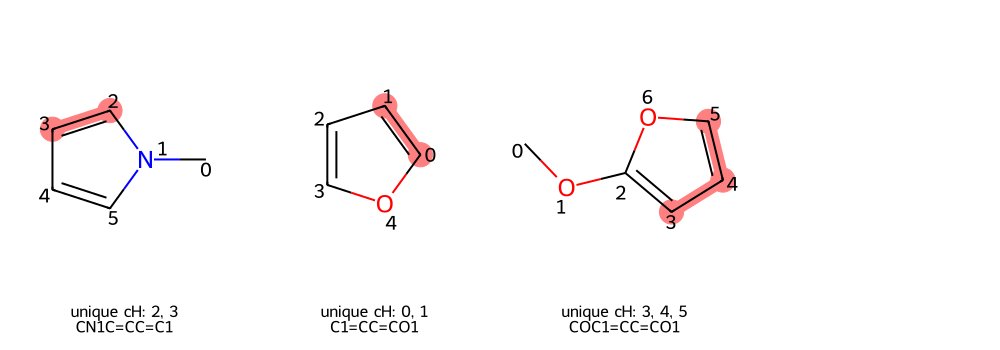

In [33]:
ft.DrawUniqueChGrid(
    raw_screen.loc[raw_screen["role"].eq("substrate"), ["compound_name", "smiles"]],
    smiles_col="smiles",
)


Now read and normalize the screen. This is where role aliases, missing names,
and catalyst `rpos` handling are resolved.


In [34]:
components = ft.screen.read(raw_screen)
components


,role,smiles,compound_name,rpos,series
0,substrate,CN1C=CC=C1,n_methyl_pyrrole,,pyrrole
1,substrate,C1=CC=CO1,furan,,furan
2,substrate,COC1=CC=CO1,methoxyfuran,"3,5",furan
3,catalyst,CC1(C)CCCC(C)(C)N1C2=CC=CC=C2B,tmp_bcat,,baseline
4,catalyst,CN(C)c1ccccc1B,dimethyl_anilino_bcat,,small_cat


The actual `rpos` expansion happens later, during TS generation. You can ask the
same parser what each substrate row will expand to.


In [35]:
rpos_preview = []
for _, row in components.query("role == 'substrate'").iterrows():
    rpos_values = parse_rpos_value(row["rpos"], row["smiles"])
    rpos_preview.append(
        {
            "substrate_name": row["compound_name"],
            "smiles": row["smiles"],
            "rpos_input": row["rpos"],
            "expanded_rpos": rpos_values,
        }
    )

pd.DataFrame(rpos_preview)


,substrate_name,smiles,rpos_input,expanded_rpos
0,n_methyl_pyrrole,CN1C=CC=C1,,"(2, 3)"
1,furan,C1=CC=CO1,,"(0, 1)"
2,methoxyfuran,COC1=CC=CO1,"3,5","(3, 5)"


## 2. Catalyst Role Matching

The new workflow is flexible because the catalyst is not identified by fixed
atom numbers. FRUST searches for one B-aryl-N scaffold:

```text
cat_B - aryl ring - cat_N
```

As long as that motif is unique, the rest of the catalyst can change. This is
why the smaller dimethyl anilino borane catalyst also works.


In [36]:
catalyst_rows = components.query("role == 'catalyst'")
catalyst_mols = []
catalyst_highlights = []
catalyst_legends = []
role_records = []

for _, row in catalyst_rows.iterrows():
    mol = Chem.AddHs(mol_from_smiles(row["smiles"], label=row["compound_name"]))
    roles = match_catalyst_roles(mol, catalyst_name=row["compound_name"])
    for role, atom_idx in roles.items():
        mol.GetAtomWithIdx(int(atom_idx)).SetProp("atomNote", f"{role}:{atom_idx}")
        role_records.append(
            {
                "catalyst_name": row["compound_name"],
                "role": role,
                "atom_index": int(atom_idx),
                "element": mol.GetAtomWithIdx(int(atom_idx)).GetSymbol(),
            }
        )
    catalyst_mols.append(mol)
    catalyst_highlights.append([int(idx) for idx in roles.values()])
    catalyst_legends.append(row["compound_name"])

pd.DataFrame(role_records)


,catalyst_name,role,atom_index,element
0,tmp_bcat,cat_B,16,B
1,tmp_bcat,cat_N,9,N
2,dimethyl_anilino_bcat,cat_B,9,B
3,dimethyl_anilino_bcat,cat_N,1,N


In [37]:
ft.MolTo3DGrid(
    catalyst_mols,
    legends=catalyst_legends,
    highlightAtoms=catalyst_highlights,
    show_labels=True,
    show_confs=False,
    columns=2,
    linked=True,
    cell_size=(520, 430),
)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

This is the first major difference from the old transformer workflow. The old
code knew the atom indices because the template XYZ had a fixed atom order. The
new code asks: which atoms in this new catalyst play the `cat_B` and `cat_N`
roles?

Everything downstream uses those role names, not hard-coded catalyst indices.


## 3. Expand Components Into Substrate-Catalyst Systems

`ft.screen.expand(...)` makes the combinatorics explicit. This still does not
create TS structures. It only says which substrate-catalyst pairs should be
screened.


In [38]:
systems = ft.screen.expand(components)
systems[
    [
        "system_name",
        "substrate_name",
        "catalyst_name",
        "rpos",
        "substrate_series",
        "catalyst_series",
    ]
]


,system_name,substrate_name,catalyst_name,rpos,substrate_series,catalyst_series
0,n_methyl_pyrrole__tmp_bcat,n_methyl_pyrrole,tmp_bcat,,pyrrole,baseline
1,n_methyl_pyrrole__dimethyl_anilino_bcat,n_methyl_pyrrole,dimethyl_anilino_bcat,,pyrrole,small_cat
2,furan__tmp_bcat,furan,tmp_bcat,,furan,baseline
3,furan__dimethyl_anilino_bcat,furan,dimethyl_anilino_bcat,,furan,small_cat
4,methoxyfuran__tmp_bcat,methoxyfuran,tmp_bcat,"3,5",furan,baseline
5,methoxyfuran__dimethyl_anilino_bcat,methoxyfuran,dimethyl_anilino_bcat,"3,5",furan,small_cat


With 3 substrates and 2 catalysts, we get 6 systems. The final TS dataframe is
larger because every system can expand over multiple `rpos` values, TS types,
and conformers.


## 4. Generate TS1-TS4 Dataframes

Now FRUST creates the transition-state guesses. Each TS family is returned as a
separate dataframe so it can be inspected and sent to constrained calculations
without mixing TS types.


In [39]:
ts_guesses = ft.screen.create_ts_guesses(
    systems,
    ts_types=["TS1", "TS2", "TS3", "TS4"],
    n_confs=1,
)

pd.DataFrame(
    [
        {
            "ts_type": ts_type,
            "rows": len(df),
            "unique_systems": df["system_name"].nunique(),
            "rpos_values": tuple(sorted(df["rpos"].unique())),
        }
        for ts_type, df in ts_guesses.items()
    ]
)


,ts_type,rows,unique_systems,rpos_values
0,TS1,12,6,"(0, 1, 2, 3, 5)"
1,TS2,12,6,"(0, 1, 2, 3, 5)"
2,TS3,12,6,"(0, 1, 2, 3, 5)"
3,TS4,12,6,"(0, 1, 2, 3, 5)"


In [40]:
ts_guesses["TS1"][
    [
        "custom_name",
        "system_name",
        "substrate_name",
        "catalyst_name",
        "structure_type",
        "rpos",
        "cid",
        "ts_spec_id",
    ]
].head(8)


,custom_name,system_name,substrate_name,catalyst_name,structure_type,rpos,cid,ts_spec_id
0,TS1(n_methyl_pyrrole__tmp_bcat_rpos(2)),n_methyl_pyrrole__tmp_bcat,n_methyl_pyrrole,tmp_bcat,TS1,2,0,TS1::builtin::methylpyrrole_v1
1,TS1(n_methyl_pyrrole__tmp_bcat_rpos(3)),n_methyl_pyrrole__tmp_bcat,n_methyl_pyrrole,tmp_bcat,TS1,3,0,TS1::builtin::methylpyrrole_v1
2,TS1(n_methyl_pyrrole__dimethyl_anilino_bcat_rpos(2)),n_methyl_pyrrole__dimethyl_anilino_bcat,n_methyl_pyrrole,dimethyl_anilino_bcat,TS1,2,0,TS1::builtin::methylpyrrole_v1
3,TS1(n_methyl_pyrrole__dimethyl_anilino_bcat_rpos(3)),n_methyl_pyrrole__dimethyl_anilino_bcat,n_methyl_pyrrole,dimethyl_anilino_bcat,TS1,3,0,TS1::builtin::methylpyrrole_v1
4,TS1(furan__tmp_bcat_rpos(0)),furan__tmp_bcat,furan,tmp_bcat,TS1,0,0,TS1::builtin::methylpyrrole_v1
5,TS1(furan__tmp_bcat_rpos(1)),furan__tmp_bcat,furan,tmp_bcat,TS1,1,0,TS1::builtin::methylpyrrole_v1
6,TS1(furan__dimethyl_anilino_bcat_rpos(0)),furan__dimethyl_anilino_bcat,furan,dimethyl_anilino_bcat,TS1,0,0,TS1::builtin::methylpyrrole_v1
7,TS1(furan__dimethyl_anilino_bcat_rpos(1)),furan__dimethyl_anilino_bcat,furan,dimethyl_anilino_bcat,TS1,1,0,TS1::builtin::methylpyrrole_v1


For the rest of the notebook, use one concrete system so the atom labels and
measurements stay readable: `n_methyl_pyrrole` with `tmp_bcat` at `rpos = 2`.


In [41]:
def pick_row(ts_type, substrate="n_methyl_pyrrole", catalyst="tmp_bcat", rpos=2):
    df = ts_guesses[ts_type]
    mask = (
        df["substrate_name"].eq(substrate)
        & df["catalyst_name"].eq(catalyst)
        & df["rpos"].eq(rpos)
    )
    return df.loc[mask].iloc[0]

selected = {ts_type: pick_row(ts_type) for ts_type in ["TS1", "TS2", "TS3", "TS4"]}

pd.DataFrame(
    [
        {
            "ts_type": ts_type,
            "custom_name": row["custom_name"],
            "n_atoms": len(row["atoms"]),
            "n_stored_bonds": len(row["connectivity_bonds"]),
        }
        for ts_type, row in selected.items()
    ]
)


,ts_type,custom_name,n_atoms,n_stored_bonds
0,TS1,TS1(n_methyl_pyrrole__tmp_bcat_rpos(2)),54,54
1,TS2,TS2(n_methyl_pyrrole__tmp_bcat_rpos(2)),54,55
2,TS3,TS3(n_methyl_pyrrole__tmp_bcat_rpos(2)),74,76
3,TS4,TS4(n_methyl_pyrrole__tmp_bcat_rpos(2)),74,76


## 5. Visualize TS1-TS4 With Constrained Role Atoms

The highlighted/labeled atoms are the chemically named role atoms in
`constraint_roles`. These are the atoms used to render row-level constraints.

Use Ctrl-click and Shift-click in the viewers to measure the same distances and
angles listed in the tables below.


In [42]:
show_role_rows(
    [selected[ts_type] for ts_type in ["TS1", "TS2", "TS3", "TS4"]],
    legends=[
        "TS1: C-H activation core",
        "TS2: H-H motif",
        "TS3: HBpin B-H transfer motif",
        "TS4: catalyst B-H transfer motif",
    ],
    columns=2,
    linked=True,
)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

A useful way to debug the new workflow is to inspect the role table first, then
measure the matching atoms in the 3D viewer.


In [43]:
roles_table(selected["TS3"])


,role,atom_index,element
0,cat_B,16,B
1,cat_H,39,H
2,cat_N,9,N
3,pin_B,56,B
4,substrate_C,42,C
5,transfer_H,67,H


In [44]:
constraint_table(selected["TS3"])


,kind,roles,atoms,target,measured,delta
0,distance,transfer_H-cat_B,67-16,1.376,1.382,0.006
1,distance,transfer_H-pin_B,67-56,1.264,1.265,0.001
2,distance,transfer_H-substrate_C,67-42,2.477,2.482,0.005
3,distance,cat_B-substrate_C,16-42,1.616,1.616,0.000
4,distance,pin_B-substrate_C,56-42,2.180,2.188,0.008
5,distance,pin_B-cat_B,56-16,2.007,2.015,0.008
6,angle,cat_B-transfer_H-pin_B,16-67-56,98.890,99.031,0.141
7,angle,cat_B-substrate_C-pin_B,16-42-56,61.750,61.825,0.075


The `target` column is the built-in template value. `measured` is the distance
or angle in the generated guess. The generated structure should be close to the
core template before any optimization is run.


In [45]:
all_core_metrics = []
for ts_type, row in selected.items():
    table = constraint_table(row)
    table.insert(0, "ts_type", ts_type)
    all_core_metrics.append(table)

pd.concat(all_core_metrics, ignore_index=True)


,ts_type,kind,roles,atoms,target,measured,delta
0,TS1,distance,cat_B-transfer_H,16-53,2.077,2.077,0.000
1,TS1,distance,cat_N-transfer_H,9-53,1.513,1.513,0.000
2,TS1,distance,transfer_H-substrate_C,53-43,1.291,1.291,0.000
3,TS1,distance,cat_B-substrate_C,16-43,1.685,1.685,0.000
4,TS1,distance,cat_B-cat_N,16-9,3.062,3.062,0.000
5,TS1,angle,cat_N-transfer_H-substrate_C,9-53-43,170.134,170.134,0.000
6,TS1,angle,transfer_H-substrate_C-cat_B,53-43-16,87.487,87.487,0.000
7,TS2,distance,cat_B-transfer_H,16-53,1.656,1.699,0.043
8,TS2,distance,cat_N-n_transfer_H,9-52,1.961,1.873,-0.088
9,TS2,distance,cat_B-cat_N,16-9,3.080,3.088,0.008


## 6. What The TS Specs Contribute

The built-in `TSSpec` is the new replacement for relying on a fixed XYZ atom
order. It stores:

- role coordinates used to place the reactive core;
- role-based distances and angles;
- a legacy `constraint_atoms` order for compatibility;
- optional extra fragments such as H, H2, or HBpin.

This table summarizes the built-in specs.


In [46]:
spec_summary = []
for name, spec in BUILTIN_TS_SPECS.items():
    spec_summary.append(
        {
            "ts_type": name,
            "spec_id": spec.spec_id,
            "role_coordinates": tuple(spec.role_coordinates),
            "extra_fragment": spec.extra_fragment,
            "constraint_order": spec.constraint_order,
            "n_constraints": len(spec.constraints),
        }
    )

pd.DataFrame(spec_summary)


,ts_type,spec_id,role_coordinates,extra_fragment,constraint_order,n_constraints
0,TS1,TS1::builtin::methylpyrrole_v1,"(transfer_H, cat_B, cat_N, substrate_C)",H,"(cat_B, cat_N, transfer_H, substrate_C)",7
1,TS2,TS2::builtin::methylpyrrole_v1,"(cat_B, cat_N, cat_H, transfer_H, n_transfer_H, substrate_C)",H2,"(cat_B, cat_N, cat_H, transfer_H, n_transfer_H, substrate_C)",4
2,TS3,TS3::builtin::methylpyrrole_tmp_v1,"(cat_B, transfer_H, cat_H, pin_B, substrate_C, cat_N)",HBpin,"(cat_B, cat_N, cat_H, pin_B, transfer_H, substrate_C)",8
3,TS4,TS4::builtin::methylpyrrole_tmp_v1,"(cat_N, cat_B, cat_H, transfer_H, pin_B, substrate_C)",HBpin,"(cat_B, cat_N, cat_H, transfer_H, pin_B, substrate_C)",8


The key point is that `TSSpec` does not say "atom 16 must be boron". It says
"wherever `cat_B` is in this molecule, place it here and constrain it to these
other roles".


## 7. How Each TS Type Handles Hydrogens And Fragments

The TS families have different bookkeeping. The table below comes from the
actual generated rows for the same substrate/catalyst/rpos.


In [47]:
hydride_summary = []
for ts_type, row in selected.items():
    roles = row["constraint_roles"]
    hydride_summary.append(
        {
            "ts_type": ts_type,
            "roles": tuple(roles),
            "cat_H": roles.get("cat_H"),
            "transfer_H": roles.get("transfer_H"),
            "n_transfer_H": roles.get("n_transfer_H"),
            "pin_B": roles.get("pin_B"),
        }
    )

pd.DataFrame(hydride_summary)


,ts_type,roles,cat_H,transfer_H,n_transfer_H,pin_B
0,TS1,"(cat_B, cat_N, substrate_C, transfer_H)",NaN,53,NaN,NaN
1,TS2,"(cat_B, cat_N, substrate_C, cat_H, n_transfer_H, transfer_H)",39.0,53,52.0,NaN
2,TS3,"(cat_B, cat_N, substrate_C, cat_H, pin_B, transfer_H)",39.0,67,NaN,56.0
3,TS4,"(cat_B, cat_N, substrate_C, cat_H, transfer_H, pin_B)",39.0,40,NaN,57.0


Interpretation:

- `TS1` adds one hydrogen fragment as `transfer_H`.
- `TS2` keeps one catalyst B-H as `cat_H` and adds H2 as the H-H motif.
- `TS3` keeps one catalyst B-H as `cat_H`; the HBpin B-H becomes `transfer_H`.
- `TS4` removes the HBpin B-H, keeps two catalyst B-H atoms, and assigns one as
  `transfer_H`.


## 8. Stored Bonds Versus Constrained Distances

This distinction matters for interpreting the 3D structures.

`connectivity_bonds` is display/storage connectivity. It helps FRUST draw the
assembled molecule without inventing bonds from short TS contacts.

`constraint_spec` is what constrained xTB/ORCA calculations use. A pair can be
constrained without being drawn as a covalent bond.


In [48]:
bond_vs_constraint = []
for ts_type in ["TS3", "TS4"]:
    row = selected[ts_type]
    bond_vs_constraint.append(
        {
            "ts_type": ts_type,
            "cat_B-pin_B stored display bond": has_stored_bond(row, "cat_B", "pin_B"),
            "cat_B-pin_B distance constraint": has_distance_constraint(row, "cat_B", "pin_B"),
            "cat_B-substrate_C display bond": has_stored_bond(row, "cat_B", "substrate_C"),
            "pin_B-substrate_C display bond": has_stored_bond(row, "pin_B", "substrate_C"),
        }
    )

pd.DataFrame(bond_vs_constraint)


,ts_type,cat_B-pin_B stored display bond,cat_B-pin_B distance constraint,cat_B-substrate_C display bond,pin_B-substrate_C display bond
0,TS3,False,True,True,False
1,TS4,False,True,False,True


This is why `TS4` should not show a thick visual B-B bond even though the B-B
contact remains part of the constrained core geometry.


## 9. Compare With Legacy XYZ Templates

The old transformer path started from template XYZ files such as
`structures/ts3_TMP.xyz` and `structures/ts4_TMP.xyz`. Those files encoded the
geometry and atom order together.

The new workflow still uses the same chemical idea, but the template information
is now split into role coordinates, constraints, and dynamic atom matching.


In [49]:
legacy_paths = [
    ROOT / "structures" / "ts1.xyz",
    ROOT / "structures" / "ts2.xyz",
    ROOT / "structures" / "ts3_TMP.xyz",
    ROOT / "structures" / "ts4_TMP.xyz",
]

ft.MolTo3DGrid(
    [str(path) for path in legacy_paths],
    legends=[path.name for path in legacy_paths],
    show_labels=False,
    show_confs=False,
    columns=2,
    linked=True,
    cell_size=(520, 430),
)


[14:11:03] Explicit valence for atom # 10 H, 2, is greater than permitted
!!! Warning !!! Distance between atoms 13 and 12 (0.785846 A) is suspicious.
[14:11:03] Explicit valence for atom # 10 B, 5, is greater than permitted
[14:11:03] Explicit valence for atom # 11 B, 4, is greater than permitted


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Now compare generated `TS3` and `TS4` guesses for the same substrate/catalyst
against the legacy TMP files. The generated structures are not atom-index copies
of the XYZ files. They are dynamic assemblies whose role atoms are placed onto
the same kind of TMP core geometry.


In [50]:
show_role_rows(
    [selected["TS3"], selected["TS4"]],
    legends=["generated TS3 from SMILES", "generated TS4 from SMILES"],
    columns=2,
    linked=True,
)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 10. Inspect A Different Catalyst Without Changing The Template

This is the reason the screen workflow exists. We can use the same TS spec with
a different catalyst SMILES because the code remaps `cat_B` and `cat_N` for each
catalyst.


In [51]:
small_cat_rows = [
    pick_row(ts_type, catalyst="dimethyl_anilino_bcat", rpos=2)
    for ts_type in ["TS1", "TS2", "TS3", "TS4"]
]

show_role_rows(
    small_cat_rows,
    legends=[
        "small catalyst TS1",
        "small catalyst TS2",
        "small catalyst TS3",
        "small catalyst TS4",
    ],
    columns=2,
    linked=True,
)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [52]:
pd.concat(
    [constraint_table(row).assign(ts_type=row["structure_type"]) for row in small_cat_rows],
    ignore_index=True,
).head(20)


,kind,roles,atoms,target,measured,delta,ts_type
0,distance,cat_B-transfer_H,9-34,2.077,2.077,0.000,TS1
1,distance,cat_N-transfer_H,1-34,1.513,1.513,0.000,TS1
2,distance,transfer_H-substrate_C,34-24,1.291,1.291,0.000,TS1
3,distance,cat_B-substrate_C,9-24,1.685,1.685,0.000,TS1
4,distance,cat_B-cat_N,9-1,3.062,3.062,0.000,TS1
5,angle,cat_N-transfer_H-substrate_C,1-34-24,170.134,170.134,0.000,TS1
6,angle,transfer_H-substrate_C-cat_B,34-24-9,87.487,87.487,0.000,TS1
7,distance,cat_B-transfer_H,9-34,1.656,1.699,0.043,TS2
8,distance,cat_N-n_transfer_H,1-33,1.961,1.873,-0.088,TS2
9,distance,cat_B-cat_N,9-1,3.080,3.088,0.008,TS2


The role names and target constraints are the same, but the atom indices changed
because the catalyst changed. This is exactly what was hard to do with a fixed
XYZ-index transformer.


## 11. Code Map: Old Transformer Workflow Versus New Screen Workflow

The new workflow is close in spirit to the old transformer path, but the
responsibility is split differently.

The old path started with an XYZ template whose atom order was part of the
method. The transformer then grafted the substrate into that known coordinate
frame and passed legacy `constraint_atoms` to `Stepper`.

The new path starts with SMILES. It finds chemically named roles, places those
roles onto built-in template coordinates, stores the constraints in the row, and
then lets `Stepper` render constraints from the row itself.


In [53]:
workflow_map = pd.DataFrame(
    [
        {
            "old workflow concept": "Ligand/substrate list",
            "new workflow equivalent": "ft.screen.read(...) component table",
            "why it changed": "Catalysts and substrates can now live in the same CSV.",
        },
        {
            "old workflow concept": "One fixed catalyst/template XYZ",
            "new workflow equivalent": "TSSpec role coordinates and constraints",
            "why it changed": "Geometry is stored by chemical role instead of atom index.",
        },
        {
            "old workflow concept": "transformer.py grafting",
            "new workflow equivalent": "frust.tsguess.assembly role assignment and assembly",
            "why it changed": "Substrate/catalyst atoms are matched dynamically from SMILES.",
        },
        {
            "old workflow concept": "embedder.py / RDKit embedding",
            "new workflow equivalent": "frust.tsguess.embedding hard anchors plus soft frames",
            "why it changed": "Disconnected fragments are placed onto a template core, then clash-ranked.",
        },
        {
            "old workflow concept": "Stepper(step_type='TS3') + constraint_atoms",
            "new workflow equivalent": "Stepper(..., constraint=True) using constraint_roles/spec",
            "why it changed": "Every generated row carries its own constraint model.",
        },
    ]
)

workflow_map


,old workflow concept,new workflow equivalent,why it changed
0,Ligand/substrate list,ft.screen.read(...) component table,Catalysts and substrates can now live in the same CSV.
1,One fixed catalyst/template XYZ,TSSpec role coordinates and constraints,Geometry is stored by chemical role instead of atom index.
2,transformer.py grafting,frust.tsguess.assembly role assignment and assembly,Substrate/catalyst atoms are matched dynamically from SMILES.
3,embedder.py / RDKit embedding,frust.tsguess.embedding hard anchors plus soft frames,"Disconnected fragments are placed onto a template core, then clash-ranked."
4,Stepper(step_type='TS3') + constraint_atoms,"Stepper(..., constraint=True) using constraint_roles/spec",Every generated row carries its own constraint model.


If you want to read the implementation after running this notebook, the useful
order is:

1. `frust/screen/core.py`: CSV normalization and substrate-catalyst expansion.
2. `frust/tsguess/specs.py`: built-in TS role coordinates and constraints.
3. `frust/tsguess/matching.py`: catalyst scaffold and substrate `rpos` matching.
4. `frust/tsguess/assembly.py`: role assignment, fragments, and row creation.
5. `frust/tsguess/embedding.py`: hard-anchor/soft-frame placement and clash relief.
6. `frust/stepper.py` and `frust/constraints.py`: row-first constraint rendering.


In [54]:
import inspect

signature_rows = [
    ("ft.screen.read", ft.screen.read),
    ("ft.screen.expand", ft.screen.expand),
    ("ft.screen.create_ts_guesses", ft.screen.create_ts_guesses),
    ("ft.Stepper.xtb", ft.Stepper.xtb),
]

pd.DataFrame(
    [
        {"callable": name, "signature": str(inspect.signature(fn))}
        for name, fn in signature_rows
    ]
)


,callable,signature
0,ft.screen.read,"(input_data: 'str | Path | pd.DataFrame', *, strict: 'bool' = False) -> 'pd.DataFrame'"
1,ft.screen.expand,(components: 'pd.DataFrame') -> 'pd.DataFrame'
2,ft.screen.create_ts_guesses,"(systems: 'pd.DataFrame', *, ts_types: 'tuple[str, ...] | list[str]' = ('TS1', 'TS2', ..."
3,ft.Stepper.xtb,"(self, df: pandas.core.frame.DataFrame, name: str = 'xtb', options: dict | None = None..."


## 12. Row-First Stepper Constraints

`Stepper(..., constraint=True)` now checks the row first. If the row has
`constraint_roles` and `constraint_spec`, those are rendered directly. The older
`step_type + constraint_atoms` path remains as a fallback for legacy workflows.

Here is the actual xTB constraint block for the selected `TS3` row.


In [55]:
print(render_xtb_constraints(selected["TS3"]))


$constrain
force constant=50
distance: 68, 17, 1.376
distance: 68, 57, 1.264
distance: 68, 43, 2.477
distance: 17, 43, 1.616
distance: 57, 43, 2.18
distance: 57, 17, 2.007
angle: 17, 68, 57, 98.89
angle: 17, 43, 57, 61.75
$end


The same row can also render ORCA-style constraints:


In [56]:
print(render_orca_constraints(selected["TS3"]))


%geom Constraints
  {B 67 16 1.376 C}
  {B 67 56 1.264 C}
  {B 67 42 2.477 C}
  {B 16 42 1.616 C}
  {B 56 42 2.18 C}
  {B 56 16 2.007 C}
  {A 16 67 56 98.89 C}
  {A 16 42 56 61.75 C}
end
end


Run a constrained pre-optimization like this. The cell is disabled by default so
that the notebook stays fast and executable without external xTB setup.


In [57]:
RUN_XTB = False

if RUN_XTB:
    step = ft.Stepper(n_cores=4, save_output_dir=False)
    ts3_preopt = step.xtb(
        ts_guesses["TS3"].head(4),
        name="xtb_preopt",
        options={"gfnff": None, "opt": None},
        constraint=True,
    )
    ts3_lowest = ft.lowest_energy_rows(ts3_preopt)
    ft.plot_mols(ts3_lowest, range(0, len(ts3_lowest)))
else:
    print("Set RUN_XTB = True to run the optional constrained xTB example.")


Set RUN_XTB = True to run the optional constrained xTB example.


## 13. Practical Debugging Checklist

When a generated TS looks suspicious, debug in this order:

1. Check the input `rpos` with `ft.DrawUniqueChGrid`.
2. Check catalyst role matching: is there exactly one B-aryl-N motif?
3. Inspect `constraint_roles`: do the role atoms make chemical sense?
4. Use `show_role_rows(...)` and Ctrl/Shift-click to measure the core.
5. Compare `constraint_table(row)` against `ts_core_metrics`.
6. Check whether a contact is a stored display bond or only a distance
   constraint.
7. Only then decide whether the template chemistry is outside the current
   calibrated space.

A good generated guess does not have to be a final DFT TS. It should have the
right chemically recognizable reactive core and small core metric deltas. Large
changes after high-level optimization are future evidence that this substrate or
catalyst class may need a calibrated template or full TS optimization route.
